In [1]:
# Import libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# Load preprocessed data
X_train = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\X_train.npy')
X_test  = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\X_test.npy')
y_train = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\y_train.npy')
y_test  = np.load(r'C:\Users\Dhairy Jani\upi-fraud-detector\data\processed\y_test.npy')

print("Data loaded!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Using device: cpu
Data loaded!
X_train shape: (454902, 30)
X_test shape: (56962, 30)


In [2]:
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Tensors created!")
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

# Create DataLoader - feeds data in batches to the model
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

print("\nDataLoader created!")
print("Total batches per epoch:", len(train_loader))

Tensors created!
X_train_tensor shape: torch.Size([454902, 30])
y_train_tensor shape: torch.Size([454902, 1])

DataLoader created!
Total batches per epoch: 1777


In [3]:
# Build Neural Network
class FraudDetectorNN(nn.Module):
    
    def __init__(self, input_size):
        super().__init__()
        
        self.network = nn.Sequential(
            # Layer 1 - input to 64 neurons
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2 - 64 to 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Output layer - 32 to 1 (fraud score)
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Create model
input_size = X_train.shape[1]
model = FraudDetectorNN(input_size)

print("Neural Network created!")
print(model)
print("\nInput size:", input_size)

Neural Network created!
FraudDetectorNN(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Input size: 30


In [4]:
# Training setup
criterion = nn.BCELoss()                           # Loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Optimizer

# Training loop
epochs = 10
train_losses = []

print("Starting training...")
print("-" * 40)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        # Step 1 - Clear old gradients
        optimizer.zero_grad()
        
        # Step 2 - Forward pass (make prediction)
        output = model(batch_X)
        
        # Step 3 - Calculate loss (how wrong are we?)
        loss = criterion(output, batch_y)
        
        # Step 4 - Backward pass (calculate gradients)
        loss.backward()
        
        # Step 5 - Update weights
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("-" * 40)
print("Training complete!")

Starting training...
----------------------------------------
Epoch 1/10 - Loss: 0.0686
Epoch 2/10 - Loss: 0.0241
Epoch 3/10 - Loss: 0.0193
Epoch 4/10 - Loss: 0.0177
Epoch 5/10 - Loss: 0.0164
Epoch 6/10 - Loss: 0.0159
Epoch 7/10 - Loss: 0.0156
Epoch 8/10 - Loss: 0.0154
Epoch 9/10 - Loss: 0.0152
Epoch 10/10 - Loss: 0.0148
----------------------------------------
Training complete!


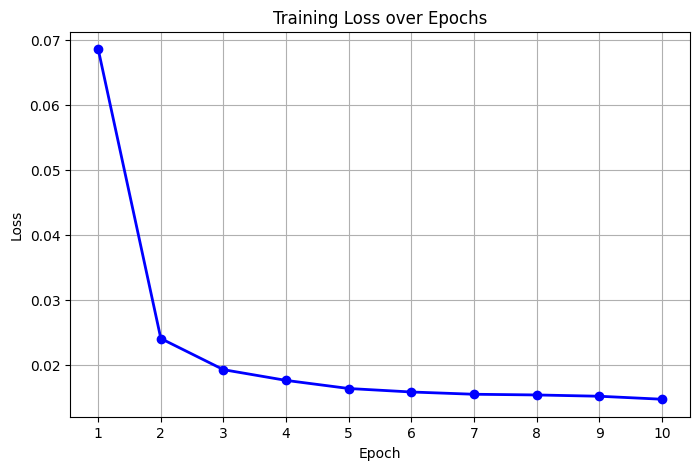

In [5]:
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, 
         color='blue', marker='o', linewidth=2)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, epochs+1))
plt.grid(True)
plt.show()

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.58      0.86      0.69        98

    accuracy                           1.00     56962
   macro avg       0.79      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962



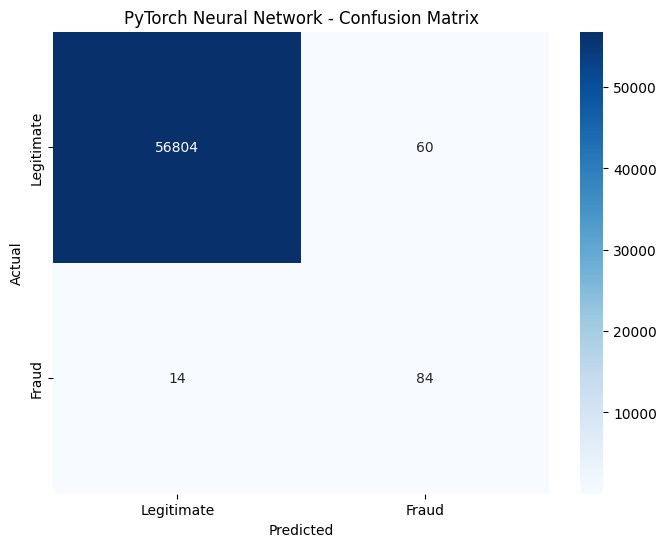

In [6]:
# Test the model
model.eval()  # Switch to evaluation mode

with torch.no_grad():  # No gradient calculation needed during testing
    y_pred_prob = model(X_test_tensor)  # Get probabilities
    y_pred = (y_pred_prob >= 0.5).float()  # Convert to 0 or 1

# Convert tensors to numpy for sklearn metrics
y_pred_np = y_pred.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Classification Report:")
print(classification_report(y_test_np, y_pred_np))

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_np)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('PyTorch Neural Network - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
# Generate Fraud Risk Score (0-100)
model.eval()

with torch.no_grad():
    risk_scores = model(X_test_tensor).numpy().flatten() * 100

# Show sample scores
print("Sample Fraud Risk Scores:")
print("-" * 40)
for i in range(10):
    actual = "FRAUD" if y_test[i] == 1 else "LEGIT"
    score  = risk_scores[i]
    risk   = "🔴 HIGH" if score > 70 else "🟡 MEDIUM" if score > 30 else "🟢 LOW"
    print(f"Transaction {i+1}: Score={score:.1f}/100 | Actual={actual} | Risk={risk}")

Sample Fraud Risk Scores:
----------------------------------------
Transaction 1: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 2: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 3: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 4: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 5: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 6: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 7: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 8: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 9: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW
Transaction 10: Score=0.0/100 | Actual=LEGIT | Risk=🟢 LOW


In [8]:
# Show fraud transactions specifically
print("Fraud Transaction Risk Scores:")
print("-" * 40)

fraud_count = 0
for i in range(len(y_test)):
    if y_test[i] == 1:  # Only fraud transactions
        score = risk_scores[i]
        risk  = "🔴 HIGH" if score > 70 else "🟡 MEDIUM" if score > 30 else "🟢 LOW"
        print(f"Transaction {i}: Score={score:.1f}/100 | Actual=FRAUD | Risk={risk}")
        fraud_count += 1
        if fraud_count == 10:  # Show only first 10 frauds
            break

Fraud Transaction Risk Scores:
----------------------------------------
Transaction 840: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 1146: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 3287: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 4276: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 5077: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 5453: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 7164: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 7299: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 7337: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH
Transaction 9036: Score=100.0/100 | Actual=FRAUD | Risk=🔴 HIGH


In [9]:
# Save PyTorch model
import joblib

torch.save(model.state_dict(), 
           r'C:\Users\Dhairy Jani\upi-fraud-detector\models\pytorch_nn.pth')

# Save model architecture info
model_info = {
    'input_size': input_size,
    'model_class': 'FraudDetectorNN'
}
joblib.dump(model_info, 
            r'C:\Users\Dhairy Jani\upi-fraud-detector\models\model_info.pkl')

print("PyTorch model saved successfully!")
print("Files saved:")
print("  models/pytorch_nn.pth      - Model weights")
print("  models/model_info.pkl      - Model architecture info")

PyTorch model saved successfully!
Files saved:
  models/pytorch_nn.pth      - Model weights
  models/model_info.pkl      - Model architecture info
